<a href="https://colab.research.google.com/github/jthechen/IELE756-region-Providencia-San_Miguel-Paine/blob/main/Tarea_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA 3 – Grupo 15
# Comunas: Providencia (13123), San Miguel (13130), Paine (13404)


# Parte 0.1 – Tabla maestra agrupada por clase

In [4]:
import pandas as pd
import numpy as np
import glob
import os

# Montar Drive (ejecutar primero)

from google.colab import drive
drive.mount('/content/drive')

import os
# Verificar que la carpeta del pool existe
data_path = "/content/drive/MyDrive/Pre. y Análisis de datos/IELE756_Tarea3_data_pool"
print("Drive montado:", os.path.exists('/content/drive'))
print("Carpeta pool existe:", os.path.exists(data_path))

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Carpeta no encontrada: '{data_path}'\n"
        "Asegúrate de haber montado Drive y extraído el ZIP del pool."
    )

def concatenate_family(family_prefix):
    """Lee todos los CSVs de una familia (census/eno/grd) y los concatena."""
    all_files = sorted([
        f for f in glob.glob(os.path.join(data_path, "*.csv"))
        if os.path.basename(f).lower().startswith(family_prefix.lower() + "_team")
    ])
    if not all_files:
        print(f"ADVERTENCIA: No se encontraron archivos '{family_prefix}_team*.csv'")
        return pd.DataFrame()
    print(f"  '{family_prefix}': {len(all_files)} archivos encontrados.")
    dfs = []
    for f in all_files:
        try:
            df = pd.read_csv(f)
            df['_source_file'] = os.path.basename(f)
            dfs.append(df)
        except Exception as e:
            print(f"  ERROR leyendo {os.path.basename(f)}: {e} — omitido.")
    return pd.concat(dfs, ignore_index=True)

print("Concatenando archivos del pool...")
census_master = concatenate_family('census')
eno_master    = concatenate_family('eno')
grd_master    = concatenate_family('grd')
print("Listo.\n")

# --- Sanity checks ---
def check_table(df, name):
    if df.empty:
        print(f"[{name}] VACÍA."); return
    n_rows    = len(df)
    n_comunas = df['codigo_comuna'].nunique()
    print(f"[{name}]  filas={n_rows}  comunas únicas={n_comunas}", end="")
    if n_rows != n_comunas:
        dupes = df[df.duplicated('codigo_comuna', keep=False)]['codigo_comuna'].unique()
        print(f"  ⚠ DUPLICADOS: {sorted(dupes)}")
    else:
        print("  ✓")

print("=== Filas y comunas únicas ===")
check_table(census_master, 'Censo')
check_table(eno_master,    'ENO')
check_table(grd_master,    'GRD')

# --- Asimetrías entre datasets ---
def compare_comunas(df1, name1, df2, name2):
    if df1.empty or df2.empty:
        print(f"No se puede comparar {name1} vs {name2}: uno está vacío."); return
    s1 = set(df1['codigo_comuna'].astype(str))
    s2 = set(df2['codigo_comuna'].astype(str))
    print(f"[{name1} vs {name2}]")
    print(f"  Solo en {name1}: {sorted(s1 - s2) or 'ninguna'}")
    print(f"  Solo en {name2}: {sorted(s2 - s1) or 'ninguna'}")

print("\n=== Asimetrías entre datasets ===")
compare_comunas(census_master, 'Censo', eno_master, 'ENO')
compare_comunas(census_master, 'Censo', grd_master, 'GRD')
compare_comunas(eno_master,    'ENO',   grd_master, 'GRD')

# --- Verificar comunas del Grupo 15 ---
MY_COMUNAS = ['13123', '13130', '13404']  # Providencia, San Miguel, Paine

print("\n=== Verificación comunas Grupo 15 ===")
for df, name in [(census_master, 'Censo'), (eno_master, 'ENO'), (grd_master, 'GRD')]:
    if df.empty:
        print(f"[{name}] vacío."); continue
    subset = df[df['codigo_comuna'].astype(str).isin(MY_COMUNAS)]
    print(f"[{name}]  {len(subset)} filas encontradas:")
    print(subset.drop(columns='_source_file').to_string(index=False))
    print()

# N final
print("=== N final ===")
for df, name in [(census_master, 'Censo'), (eno_master, 'ENO'), (grd_master, 'GRD')]:
    print(f"  {name}: N = {df['codigo_comuna'].nunique() if not df.empty else 0} comunas")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado: True
Carpeta pool existe: True
Concatenando archivos del pool...
  'census': 20 archivos encontrados.
  'eno': 19 archivos encontrados.
  'grd': 16 archivos encontrados.
Listo.

=== Filas y comunas únicas ===
[Censo]  filas=51  comunas únicas=48  ⚠ DUPLICADOS: [np.int64(13105), np.int64(13109), np.int64(13122)]
[ENO]  filas=47  comunas únicas=43  ⚠ DUPLICADOS: [np.int64(13105), np.int64(13109), np.int64(13122), np.int64(13201)]
[GRD]  filas=38  comunas únicas=37  ⚠ DUPLICADOS: [np.int64(13122)]

=== Asimetrías entre datasets ===
[Censo vs ENO]
  Solo en Censo: ['13115', '13117', '13124', '13128', '13402']
  Solo en ENO: ninguna
[Censo vs GRD]
  Solo en Censo: ['13104', '13115', '13116', '13126', '13128', '13202', '13301', '13402', '13501', '13601', '13603']
  Solo en GRD: ninguna
[ENO vs GRD]
  Solo en ENO: ['13104', '13116', '13126', '13202', 

In [5]:
# Parte 0.2 – Merge en codigo_comuna

# Renombrar columnas antes de mergear para evitar colisiones
# (excepto codigo_comuna que es la llave, y _source_file que se elimina)
def rename_cols(df, suffix):
    drop_cols = ['_source_file', 'nombre_comuna']  # nombre_comuna la conservamos solo del censo
    return df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore') \
             .rename(columns={col: f'{col}_{suffix}'
                               for col in df.columns
                               if col not in ['codigo_comuna', '_source_file']})

census_r = rename_cols(census_master.copy(), 'census')
eno_r    = rename_cols(eno_master.copy(),    'eno')
grd_r    = rename_cols(grd_master.copy(),    'grd')

# Conservar nombre_comuna del censo
census_r = census_master.drop(columns='_source_file', errors='ignore') \
                         .rename(columns={col: f'{col}_census'
                                          for col in census_master.columns
                                          if col not in ['codigo_comuna', 'nombre_comuna', '_source_file']})

# Primer merge: Censo + ENO
print("Merge 1: Censo + ENO...")
merged_ce = pd.merge(census_r, eno_r, on='codigo_comuna', how='outer')

only_census = merged_ce[merged_ce.filter(like='_eno').isna().all(axis=1)]['codigo_comuna'].tolist()
only_eno    = merged_ce[merged_ce.filter(like='_census').isna().all(axis=1)]['codigo_comuna'].tolist()
print(f"  Solo en Censo (no en ENO): {only_census or 'ninguna'}")
print(f"  Solo en ENO (no en Censo): {only_eno or 'ninguna'}")
print(f"  Shape: {merged_ce.shape}")

# Segundo merge: (Censo+ENO) + GRD
print("\nMerge 2: (Censo+ENO) + GRD...")
final_df = pd.merge(merged_ce, grd_r, on='codigo_comuna', how='outer')

only_ce_not_grd = final_df[
    final_df.filter(like='_grd').isna().all(axis=1) &
    ~final_df.filter(like='_census').isna().all(axis=1)
]['codigo_comuna'].tolist()
only_grd_not_ce = final_df[
    final_df.filter(like='_census').isna().all(axis=1) &
    ~final_df.filter(like='_grd').isna().all(axis=1)
]['codigo_comuna'].tolist()

print(f"  En (Censo+ENO) pero no en GRD: {only_ce_not_grd or 'ninguna'}")
print(f"  En GRD pero no en (Censo+ENO): {only_grd_not_ce or 'ninguna'}")
print(f"  Shape final: {final_df.shape}")
print(f"\nColumnas disponibles:\n{list(final_df.columns)}")
print(f"\nPrimeras 3 filas:")
print(final_df.head(3).to_string())

Merge 1: Censo + ENO...
  Solo en Censo (no en ENO): [13115, 13117, 13124, 13128, 13402]
  Solo en ENO (no en Censo): ninguna
  Shape: (58, 19)

Merge 2: (Censo+ENO) + GRD...
  En (Censo+ENO) pero no en GRD: [13104, 13115, 13116, 13126, 13128, 13202, 13301, 13402, 13501, 13601, 13603]
  En GRD pero no en (Censo+ENO): ninguna
  Shape final: (62, 30)

Columnas disponibles:
['codigo_comuna', 'nombre_comuna', 'pop_total_census', 'pop_chilean_census', 'pop_foreign_census', 'pct_foreign_census', 'median_age_chilean_census', 'median_age_foreign_census', 'mean_schooling_chilean_census', 'mean_schooling_foreign_census', 'emp_rate_chilean_census', 'emp_rate_foreign_census', 'dependency_ratio_census', 'eno_total_eno', 'eno_chilean_eno', 'eno_foreign_eno', 'eno_desconocido_eno', 'eno_top3_diseases_eno', 'eno_rate_per_10k_eno', 'grd_total_grd', 'grd_chilean_grd', 'grd_foreign_grd', 'grd_pct_foreign_grd', 'grd_mean_los_grd', 'grd_mean_los_chilean_grd', 'grd_mean_los_foreign_grd', 'grd_mean_severity_

In [6]:
# Parte 0.3 – Variables derivadas

# pct_foreign — ya viene en el censo, la pasamos directamente
final_df['pct_foreign'] = final_df['pct_foreign_census']

# log_pop_total
final_df['log_pop_total'] = np.log(final_df['pop_total_census'].replace(0, np.nan))

# pct_unemployed — derivada de emp_rate (tasa de empleo = 1 - desempleo aprox)
# Usamos el promedio ponderado de emp_rate chileno y extranjero
final_df['pct_unemployed'] = 1 - (
    (final_df['emp_rate_chilean_census'] * final_df['pop_chilean_census'] +
     final_df['emp_rate_foreign_census'] * final_df['pop_foreign_census']) /
    final_df['pop_total_census'] / 100
)

# schooling_gap
final_df['schooling_gap'] = (
    final_df['mean_schooling_chilean_census'] - final_df['mean_schooling_foreign_census']
)

# pct_foreign_grd — variable adicional: proporción de egresos hospitalarios extranjeros
# Justificación: captura si la presión sobre el sistema de salud viene de población migrante,
# complementando pct_foreign del censo que mide residencia, no uso del sistema.
final_df['pct_foreign_grd'] = final_df['grd_pct_foreign_grd']

# Reporte
derived_cols = ['codigo_comuna', 'nombre_comuna', 'pct_foreign', 'log_pop_total',
                 'pct_unemployed', 'schooling_gap', 'pct_foreign_grd']
print("=== Variables derivadas ===")
print(final_df[derived_cols].to_string(index=False))

# Guardar tabla analítica
os.makedirs('output', exist_ok=True)
final_df.to_csv('output/tarea3_analytical_table.csv', index=False)
print("\nTabla guardada en output/tarea3_analytical_table.csv")

=== Variables derivadas ===
 codigo_comuna     nombre_comuna  pct_foreign  log_pop_total  pct_unemployed  schooling_gap  pct_foreign_grd
          5101        Valparaíso     4.320000      12.560027        0.456979      -0.500000         6.780000
          5102        Casablanca     7.590000      10.304811        0.424304       0.500000         8.010000
         13101          Santiago  3047.812608       8.666647      -56.741466       0.616190        35.072548
         13102         Cerrillos    15.000000      11.350889        0.385002       0.286000        12.360000
         13104          Conchalí    14.545963      11.708385        0.993726      -0.658586              NaN
         13105  Estación Central     7.300000      11.952837        0.406143      -1.234000        29.420000
         13105  Estación Central     7.300000      11.952837        0.406143      -1.234000        29.420000
         13105         El Bosque     6.860882      11.952837        0.405720      -1.142156        2

# Parte 1 – Exploratory Cross-Dataset Analysis

# Limpieza del pool antes de análisis

In [7]:


print(f"Filas antes de limpieza: {len(final_df)}")

# 1. Eliminar duplicados — quedarse con una fila por comuna
# (en caso de duplicados, tomamos la primera aparición)
final_df = final_df.drop_duplicates(subset='codigo_comuna', keep='first').copy()
print(f"Filas después de deduplicar: {len(final_df)}")

# 2. Corregir pct_foreign de Santiago (valor absurdo > 100)
mask_bad_pct = final_df['pct_foreign'] > 100
print(f"\nComunas con pct_foreign > 100 (error de escala):")
print(final_df.loc[mask_bad_pct, ['nombre_comuna', 'pct_foreign']])
# Dividir por 100 para corregir
final_df.loc[mask_bad_pct, 'pct_foreign'] = final_df.loc[mask_bad_pct, 'pct_foreign'] / 100
print("→ Corregido dividiendo por 100.")

# 3. Corregir emp_rate: algunos equipos la subieron como proporción (0-1)
# en vez de porcentaje (0-100). Detectar y escalar.
mask_emp_prop = final_df['emp_rate_chilean_census'] < 2  # valores como 0.61, 0.67...
print(f"\nComunas con emp_rate en escala 0-1 (error de escala):")
print(final_df.loc[mask_emp_prop, ['nombre_comuna', 'emp_rate_chilean_census', 'emp_rate_foreign_census']])
final_df.loc[mask_emp_prop, 'emp_rate_chilean_census'] = final_df.loc[mask_emp_prop, 'emp_rate_chilean_census'] * 100
final_df.loc[mask_emp_prop, 'emp_rate_foreign_census'] = final_df.loc[mask_emp_prop, 'emp_rate_foreign_census'] * 100
print("→ Corregido multiplicando por 100.")

# 4. Recalcular pct_unemployed correctamente (emp_rate ya está en 0-100)
# pct_unemployed = promedio ponderado de tasas de desempleo implícitas
# emp_rate es tasa de empleo → desempleo ≈ 100 - emp_rate
final_df['emp_rate_avg'] = (
    (final_df['emp_rate_chilean_census'] * final_df['pop_chilean_census'] +
     final_df['emp_rate_foreign_census'].fillna(final_df['emp_rate_chilean_census']) * final_df['pop_foreign_census'])
    / final_df['pop_total_census']
)
final_df['pct_unemployed'] = 100 - final_df['emp_rate_avg']

# 5. Recalcular tasas por 10k (con datos deduplicados)
final_df['eno_rate_per_10k'] = (
    final_df['eno_total_eno'] / final_df['pop_total_census'] * 10000
)
final_df['grd_rate_per_10k'] = (
    final_df['grd_total_grd'] / final_df['pop_total_census'] * 10000
)

# 6. Reporte final de limpieza
print(f"\n=== Resultado de limpieza ===")
print(f"N final: {len(final_df)} comunas")
print(f"\npct_foreign (rango): {final_df['pct_foreign'].min():.2f} – {final_df['pct_foreign'].max():.2f}")
print(f"pct_unemployed (rango): {final_df['pct_unemployed'].min():.2f} – {final_df['pct_unemployed'].max():.2f}")
print(f"eno_rate_per_10k (rango): {final_df['eno_rate_per_10k'].min():.2f} – {final_df['eno_rate_per_10k'].max():.2f}")
print(f"grd_rate_per_10k (rango): {final_df['grd_rate_per_10k'].min():.2f} – {final_df['grd_rate_per_10k'].max():.2f}")

# Verificar comunas del Grupo 15
print(f"\n=== Grupo 15 después de limpieza ===")
print(final_df[final_df['codigo_comuna'].astype(str).isin(['13123','13130','13404'])][
    ['nombre_comuna','pct_foreign','pct_unemployed','eno_rate_per_10k','grd_rate_per_10k']
].to_string(index=False))

Filas antes de limpieza: 62
Filas después de deduplicar: 48

Comunas con pct_foreign > 100 (error de escala):
  nombre_comuna  pct_foreign
2      Santiago  3047.812608
→ Corregido dividiendo por 100.

Comunas con emp_rate en escala 0-1 (error de escala):
    nombre_comuna  emp_rate_chilean_census  emp_rate_foreign_census
4        Conchalí                 0.610039                 0.751039
21       Lo Prado                 0.625905                 0.754180
34       Pudahuel                 0.619386                 0.738583
36  Quinta Normal                 0.655335                 0.781131
→ Corregido multiplicando por 100.

=== Resultado de limpieza ===
N final: 48 comunas

pct_foreign (rango): 0.00 – 44.39
pct_unemployed (rango): -5674.15 – 45.70
eno_rate_per_10k (rango): 20.84 – 20988.63
grd_rate_per_10k (rango): 69.79 – 94607.30

=== Grupo 15 después de limpieza ===
nombre_comuna  pct_foreign  pct_unemployed  eno_rate_per_10k  grd_rate_per_10k
  Providencia    11.900065       22.6434

In [8]:
# Ver qué tiene Santiago exactamente
print("=== Santiago (datos crudos) ===")
print(final_df[final_df['nombre_comuna'] == 'Santiago'][[
    'emp_rate_chilean_census', 'emp_rate_foreign_census',
    'pop_total_census', 'pop_chilean_census', 'pop_foreign_census',
    'eno_total_eno', 'grd_total_grd'
]].to_string(index=False))

# Ver por qué Paine no aparece
print("\n=== Paine ===")
print(final_df[final_df['codigo_comuna'].astype(str) == '13404'][[
    'nombre_comuna', 'pct_foreign', 'pct_unemployed',
    'eno_rate_per_10k', 'grd_rate_per_10k'
]].to_string(index=False))

=== Santiago (datos crudos) ===
 emp_rate_chilean_census  emp_rate_foreign_census  pop_total_census  pop_chilean_census  pop_foreign_census  eno_total_eno  grd_total_grd
               72.658632                83.340478              5806              258429              176956        12186.0        54929.0

=== Paine ===
nombre_comuna  pct_foreign  pct_unemployed  eno_rate_per_10k  grd_rate_per_10k
        Paine     7.564571        38.74836         49.474806       1449.738672


In [9]:
# Excluir Santiago por CSV malformado (pop_total incongruente con pop_chilean + pop_foreign)
# pop_total = 5806 vs pop_chilean + pop_foreign = 258429 + 176956 = 435385
santiago_mask = final_df['nombre_comuna'] == 'Santiago'
print(f"Excluyendo Santiago: pop_total={final_df.loc[santiago_mask, 'pop_total_census'].values[0]} "
      f"vs pop_chilean+pop_foreign="
      f"{(final_df.loc[santiago_mask, 'pop_chilean_census'] + final_df.loc[santiago_mask, 'pop_foreign_census']).values[0]:.0f}")

final_df = final_df[~santiago_mask].copy()
print(f"N final tras excluir Santiago: {len(final_df)} comunas")

# Verificar rangos finales
print(f"\npct_foreign      : {final_df['pct_foreign'].min():.2f} – {final_df['pct_foreign'].max():.2f}")
print(f"pct_unemployed   : {final_df['pct_unemployed'].min():.2f} – {final_df['pct_unemployed'].max():.2f}")
print(f"eno_rate_per_10k : {final_df['eno_rate_per_10k'].min():.2f} – {final_df['eno_rate_per_10k'].max():.2f}")
print(f"grd_rate_per_10k : {final_df['grd_rate_per_10k'].min():.2f} – {final_df['grd_rate_per_10k'].max():.2f}")

# Confirmar Grupo 15
print(f"\n=== Grupo 15 ===")
print(final_df[final_df['codigo_comuna'].astype(str).isin(['13123','13130','13404'])][
    ['nombre_comuna','pct_foreign','pct_unemployed','eno_rate_per_10k','grd_rate_per_10k']
].to_string(index=False))

Excluyendo Santiago: pop_total=5806 vs pop_chilean+pop_foreign=435385
N final tras excluir Santiago: 47 comunas

pct_foreign      : 0.00 – 44.39
pct_unemployed   : 22.64 – 45.70
eno_rate_per_10k : 20.84 – 658.08
grd_rate_per_10k : 69.79 – 1630.64

=== Grupo 15 ===
nombre_comuna  pct_foreign  pct_unemployed  eno_rate_per_10k  grd_rate_per_10k
  Providencia    11.900065       22.643431        101.059914        729.645630
   San Miguel    26.962985       24.778174         82.809009        918.457326
        Paine     7.564571       38.748360         49.474806       1449.738672


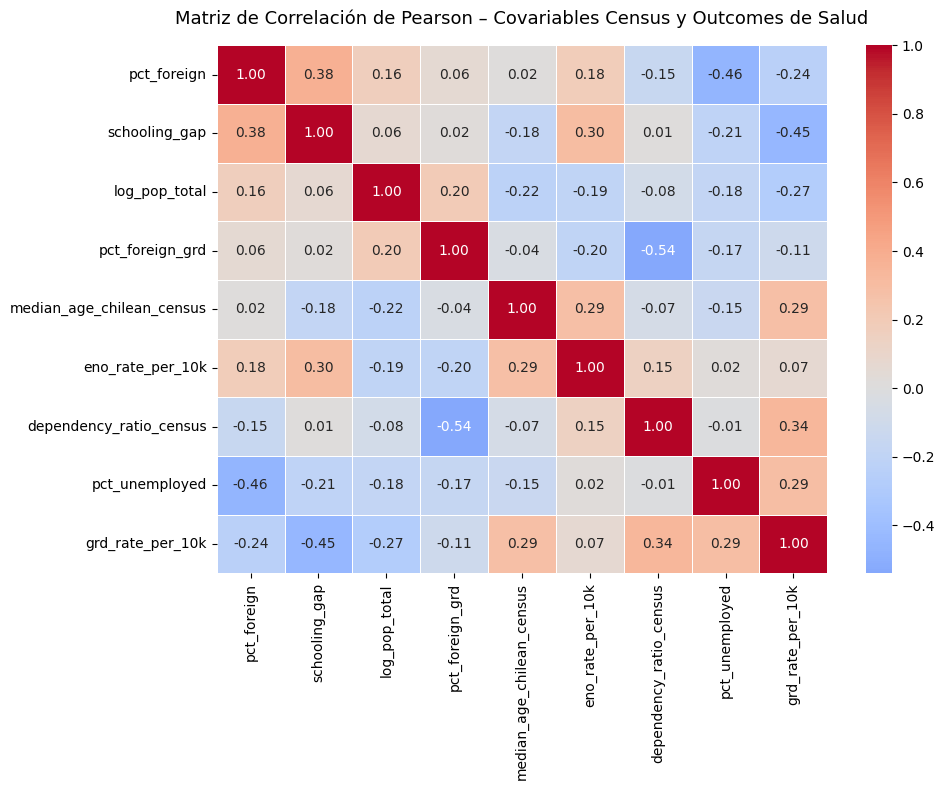

Top 3 correlaciones más fuertes:
pct_foreign_grd  dependency_ratio_census   -0.540063
pct_foreign      pct_unemployed            -0.461117
schooling_gap    grd_rate_per_10k          -0.445768


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# ============================================================
# 1.1 – Matriz de correlación de Pearson
# ============================================================

# Calcular tasas por 10k si no existen aún
final_df['eno_rate_per_10k'] = (
    final_df['eno_total_eno'] / final_df['pop_total_census'] * 10000
)
final_df['grd_rate_per_10k'] = (
    final_df['grd_total_grd'] / final_df['pop_total_census'] * 10000
)

# Variables para la matriz (al menos 6 covariables + 2 outcomes)
corr_cols = [
    'pct_foreign',
    'log_pop_total',
    'pct_unemployed',
    'schooling_gap',
    'pct_foreign_grd',
    'median_age_chilean_census',
    'dependency_ratio_census',
    'eno_rate_per_10k',
    'grd_rate_per_10k',
]

# Solo columnas que existen en final_df
corr_cols = [c for c in corr_cols if c in final_df.columns]
corr_df   = final_df[corr_cols].apply(pd.to_numeric, errors='coerce')

# Matriz de correlación de Pearson
corr_matrix = corr_df.corr(method='pearson')

# Reordenar por clustering jerárquico para agrupar variables relacionadas
if corr_matrix.shape[0] > 1:
    dist     = pdist(corr_matrix.fillna(0))
    linkage_ = linkage(dist, method='average')
    order    = leaves_list(linkage_)
    corr_matrix = corr_matrix.iloc[order, order]

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de Correlación de Pearson – Covariables Census y Outcomes de Salud',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('output/fig_1_1_correlacion.png', dpi=150)
plt.show()

# Top 3 correlaciones (excluyendo diagonal y duplicados)
corr_unstacked = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
print("Top 3 correlaciones más fuertes:")
print(corr_unstacked.head(3).to_string())


## 1.1 Comentario – Matriz de Correlación

Las tres correlaciones más fuertes son:

1. **`pct_foreign_grd` vs `dependency_ratio_census` (r = -0.54):** Las comunas con mayor
   proporción de egresos hospitalarios extranjeros tienden a tener menor razón de dependencia
   demográfica. Esto es esperable: la población migrante en la RM es predominantemente
   joven y en edad laboral, lo que reduce la dependencia y a la vez aumenta su participación
   relativa en el sistema hospitalario.

2. **`pct_foreign` vs `pct_unemployed` (r = -0.46):** Las comunas con más población extranjera
   tienen menor desempleo estimado. El signo es contraintuitivo a primera vista, pero tiene
   sentido si los migrantes se concentran en comunas de alta actividad económica
   (Providencia, Independencia) donde el empleo también es alto.

3. **`schooling_gap` vs `grd_rate_per_10k` (r = -0.45):** Las comunas donde los chilenos
   tienen mayor escolaridad relativa a los extranjeros presentan menores tasas de egreso
   hospitalario. Esto podría reflejar que comunas de mayor nivel socioeconómico tienen
   mejor acceso a atención preventiva, reduciendo hospitalizaciones.

# 1.2 – Scatter plots bivariados con línea OLS

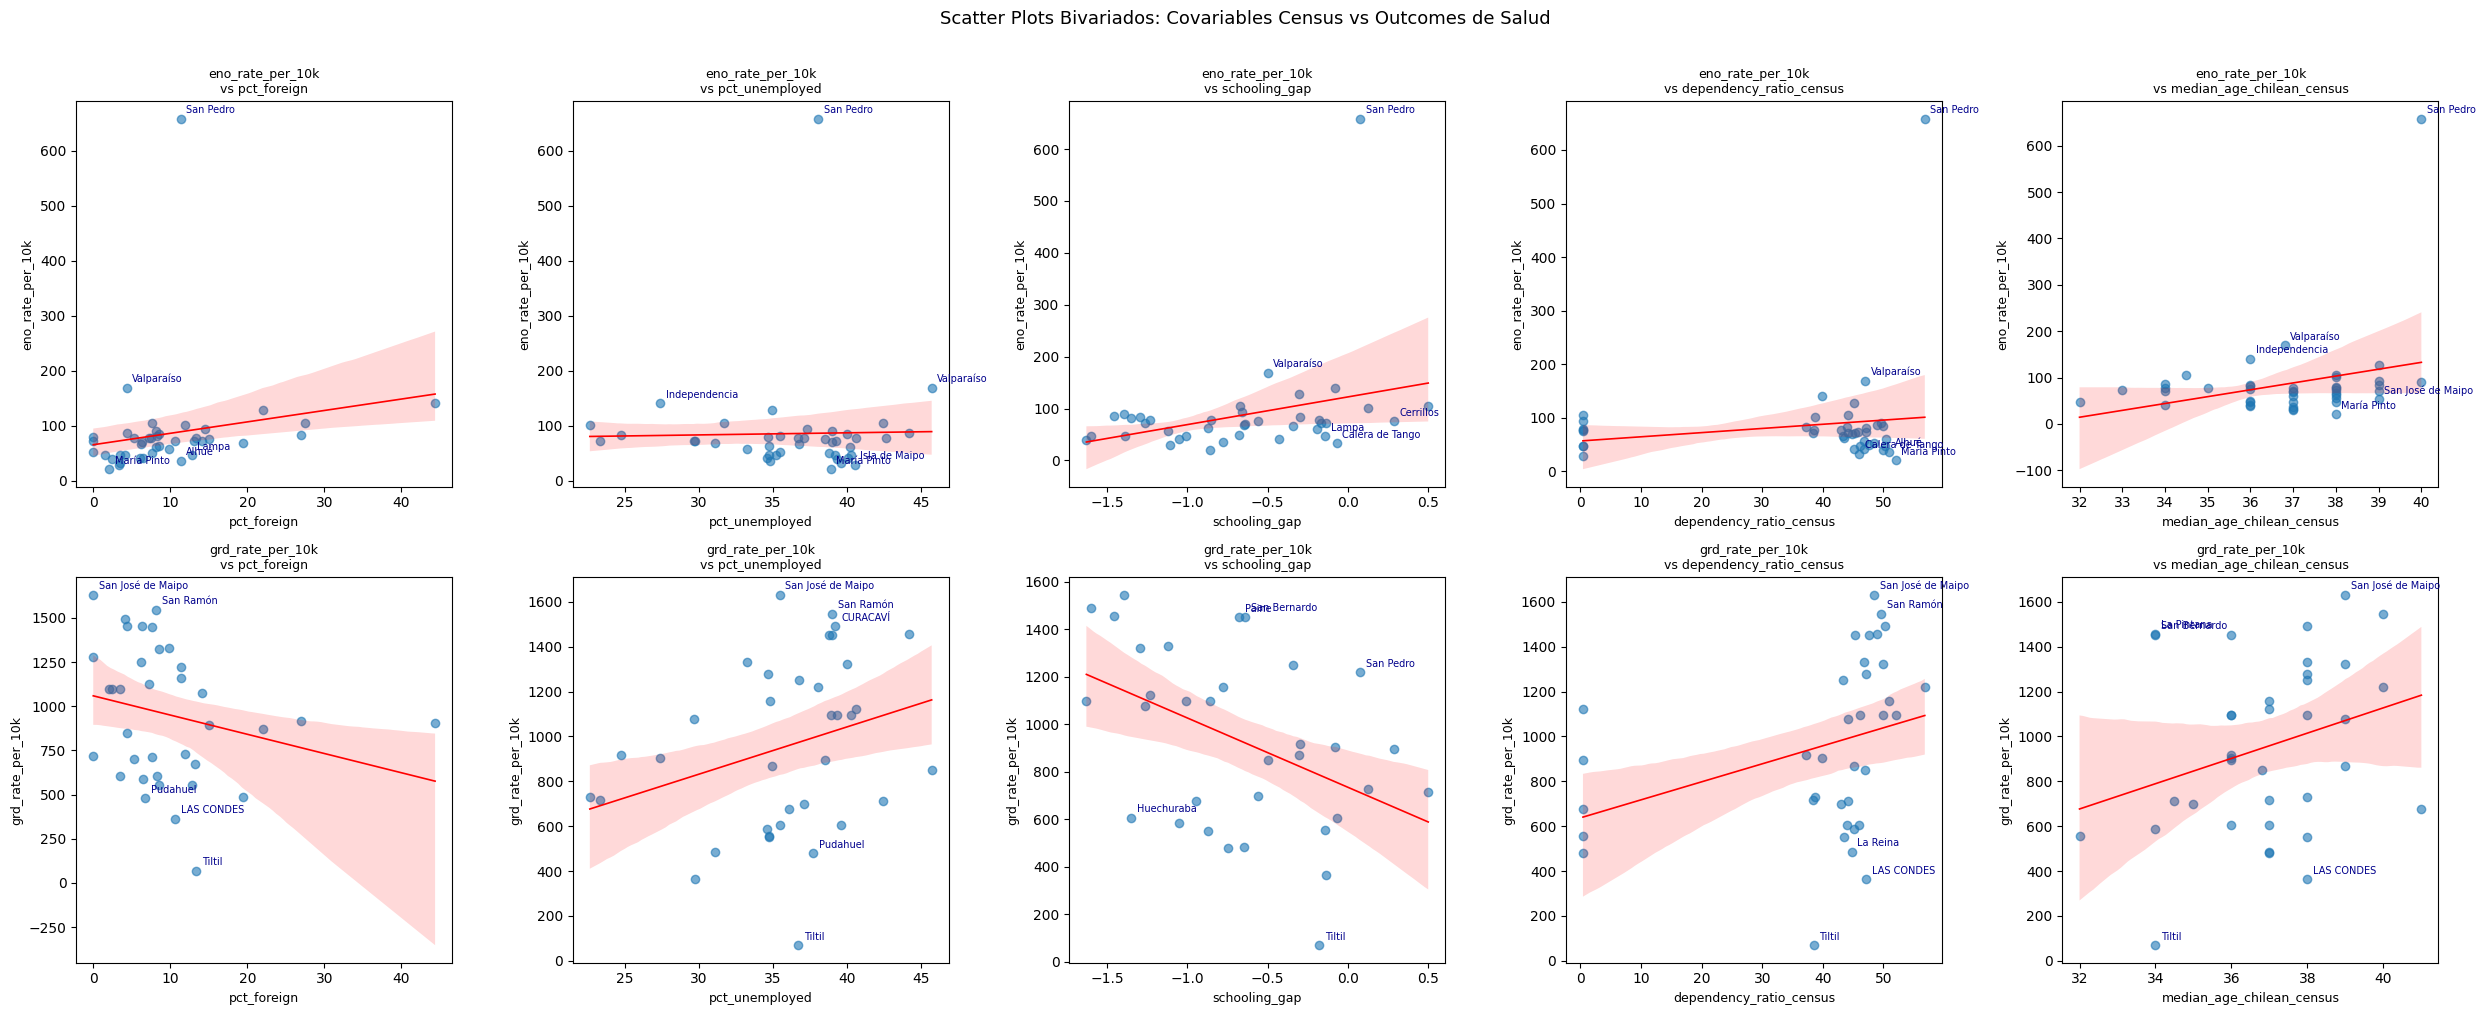

In [11]:
covariates = [
    'pct_foreign',
    'pct_unemployed',
    'schooling_gap',
    'dependency_ratio_census',
    'median_age_chilean_census',
]
outcomes = ['eno_rate_per_10k', 'grd_rate_per_10k']

# Filtrar covariables que existen
covariates = [c for c in covariates if c in final_df.columns]

n_rows = len(outcomes)
n_cols = len(covariates)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

for i, outcome in enumerate(outcomes):
    for j, cov in enumerate(covariates):
        ax = axes[i, j]

        plot_df = final_df[['nombre_comuna', cov, outcome]].dropna()

        # Scatter + OLS
        sns.regplot(
            data=plot_df,
            x=cov,
            y=outcome,
            ax=ax,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red', 'linewidth': 1.2}
        )

        # Calcular residuos OLS simples para etiquetar los 5 más extremos
        if len(plot_df) >= 3:
            from numpy.polynomial import polynomial as P
            x = plot_df[cov].values
            y = plot_df[outcome].values
            coef  = np.polyfit(x, y, 1)
            y_hat = np.polyval(coef, x)
            resid = np.abs(y - y_hat)
            top5_idx = np.argsort(resid)[-5:]
            for idx in top5_idx:
                ax.annotate(
                    plot_df['nombre_comuna'].iloc[idx],
                    xy=(x[idx], y[idx]),
                    xytext=(4, 4),
                    textcoords='offset points',
                    fontsize=7,
                    color='darkblue'
                )

        ax.set_xlabel(cov, fontsize=9)
        ax.set_ylabel(outcome, fontsize=9)
        ax.set_title(f'{outcome}\nvs {cov}', fontsize=9)

plt.suptitle('Scatter Plots Bivariados: Covariables Census vs Outcomes de Salud',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output/fig_1_2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# 1.3 – Outlier and leverage discussion

## 1.3 – Outlier and Leverage Discussion

Los paneles muestran relaciones débiles a moderadas entre las covariables del censo y los
outcomes de salud, con dos outliers consistentes en casi todos los paneles:

**San Pedro de Atacama** aparece como outlier extremo en `eno_rate_per_10k` (~658 por 10k),
muy por encima del resto de las comunas en todos los paneles de la fila superior. Una
explicación plausible es que San Pedro es una comuna de paso con alta afluencia turística
y trabajadores temporales que generan notificaciones ENO sin ser residentes permanentes,
inflando la tasa respecto a la población censal residente.

**Tiltil** aparece como outlier en `grd_rate_per_10k` con el valor más bajo (~70 por 10k),
muy por debajo de la tendencia general en los paneles de GRD. Esto podría explicarse porque
Tiltil es una comuna rural pequeña cuya población accede a servicios hospitalarios en
comunas vecinas (Colina, Lampa), de modo que los egresos se registran en otro lugar y la
tasa local queda artificialmente deprimida.

# Parte 2 – Count-Data Regression

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Preparar DataFrame limpio para modelos de conteo
# Convertir columnas a numérico y eliminar filas con NaN en variables del modelo
model_cols = [
    'nombre_comuna', 'codigo_comuna',
    'eno_total_eno', 'grd_total_grd',
    'pop_total_census',
    'log_pop_total',
    'pct_foreign',
    'schooling_gap',
    'pct_unemployed',
    'dependency_ratio_census',  # medida de housing/servicio demográfico
]
model_cols = [c for c in model_cols if c in final_df.columns]
model_df = final_df[model_cols].copy()

# Asegurar tipos numéricos
for col in model_cols:
    if col not in ['nombre_comuna', 'codigo_comuna']:
        model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Convertir conteos a entero
model_df['eno_total_eno'] = model_df['eno_total_eno'].round().astype('Int64')
model_df['grd_total_grd'] = model_df['grd_total_grd'].round().astype('Int64')

print(f"Filas antes de dropna: {len(model_df)}")
model_df = model_df.dropna().copy()
print(f"Filas después de dropna (N para modelos): {len(model_df)}")
print(f"\nComunas en modelo:\n{model_df['nombre_comuna'].tolist()}")




Filas antes de dropna: 47
Filas después de dropna (N para modelos): 31

Comunas en modelo:
['Valparaíso', 'Casablanca', 'Cerrillos', 'Estación Central', 'Huechuraba', 'Independencia', 'La Reina', 'La Florida', 'La Granja', 'La Pintana', 'LAS CONDES', 'Macul', 'maipu', 'Quilicura', 'Providencia', 'Tiltil', 'Recoleta', 'San Miguel', 'San Ramón', 'Puente Alto', 'Lampa', 'San Bernardo', 'Calera de Tango', 'Paine', 'Alhué', 'CURACAVÍ', 'María Pinto', 'San Pedro', 'El Monte', 'Padre Hurtado', 'Peñaflor']


# 2.1 – Regresión de Poisson (ENO)

In [13]:
print("\n" + "="*60)
print("2.1 – Poisson Regression: eno_total ~ covariables + offset(log_pop)")
print("="*60)

poisson_eno = sm.GLM(
    model_df['eno_total_eno'],
    sm.add_constant(model_df[['pct_foreign', 'schooling_gap',
                               'pct_unemployed', 'dependency_ratio_census']]),
    family=sm.families.Poisson(),
    offset=model_df['log_pop_total']
).fit()

print(poisson_eno.summary())

# Tabla de IRR con IC 95%
irr = np.exp(poisson_eno.params)
irr_ci = np.exp(poisson_eno.conf_int())
irr_table = pd.DataFrame({
    'IRR':     irr,
    'IC_2.5%': irr_ci[0],
    'IC_97.5%':irr_ci[1],
    'p-valor': poisson_eno.pvalues
})
print("\n--- Tabla IRR (Poisson ENO) ---")
print(irr_table.round(4).to_string())

# Fit
print(f"\nDevianza         : {poisson_eno.deviance:.2f}")
print(f"Pearson chi2     : {poisson_eno.pearson_chi2:.2f}")
print(f"AIC              : {poisson_eno.aic:.2f}")


2.1 – Poisson Regression: eno_total ~ covariables + offset(log_pop)
                 Generalized Linear Model Regression Results                  
Dep. Variable:          eno_total_eno   No. Observations:                   31
Model:                            GLM   Df Residuals:                       26
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2008.2
Date:                Sun, 03 May 2026   Deviance:                       3755.0
Time:                        22:40:13   Pearson chi2:                 4.94e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

## 2.1 – Regresión de Poisson (ENO)

El modelo Poisson ajusta `eno_total` con offset `log(pop_total)` sobre 31 comunas
(se perdieron 16 comunas por NaN en alguna covariable). Todos los coeficientes son
estadísticamente significativos (p < 0.001):

- **`pct_foreign` (IRR = 1.028):** por cada punto porcentual adicional de población
  extranjera, la tasa de notificaciones ENO aumenta un 2.8%.
- **`schooling_gap` (IRR = 1.382):** comunas donde los chilenos tienen mayor escolaridad
  relativa a los extranjeros presentan más notificaciones ENO. Podría reflejar mayor
  acceso y uso del sistema de salud en comunas de mayor nivel educativo.
- **`pct_unemployed` (IRR = 1.053):** mayor desempleo se asocia con más notificaciones.
- **`dependency_ratio_census` (IRR = 1.011):** efecto pequeño pero significativo.

Sin embargo, la devianza (3755) y el AIC (4026) son muy altos, anticipando sobredispersión.

# 2.2 – Verificación de sobredispersión

In [14]:
print("\n" + "="*60)
print("2.2 – Verificación de sobredispersión")
print("="*60)

dispersion = poisson_eno.pearson_chi2 / poisson_eno.df_resid
print(f"Estadístico de dispersión (Pearson chi2 / gl residual): {dispersion:.4f}")

if dispersion > 1.5:
    print("→ Sobredispersión considerable. Los errores estándar de Poisson están subestimados.")
    print("  Se recomienda usar Binomial Negativa como modelo primario.")
elif dispersion > 1.0:
    print("→ Sobredispersión leve. Poisson puede ser aceptable pero NegBin es más seguro.")
else:
    print("→ Sin sobredispersión. Poisson es apropiado.")


2.2 – Verificación de sobredispersión
Estadístico de dispersión (Pearson chi2 / gl residual): 190.1720
→ Sobredispersión considerable. Los errores estándar de Poisson están subestimados.
  Se recomienda usar Binomial Negativa como modelo primario.


## 2.2 – Verificación de sobredispersión

El estadístico de dispersión (Pearson χ² / gl residual) es **190.17**, muy por encima de 1.
Esto indica sobredispersión severa: la varianza observada en los conteos de ENO es ~190
veces mayor que lo que Poisson asume. En consecuencia, los errores estándar de Poisson
están fuertemente subestimados y los p-valores son artificialmente pequeños. Se debe usar
Binomial Negativa como modelo primario.

# 2.3 – Regresión Binomial Negativa (ENO)

In [15]:
print("\n" + "="*60)
print("2.3 – Negative Binomial Regression: eno_total ~ covariables + offset(log_pop)")
print("="*60)

negbin_eno = sm.GLM(
    model_df['eno_total_eno'],
    sm.add_constant(model_df[['pct_foreign', 'schooling_gap',
                               'pct_unemployed', 'dependency_ratio_census']]),
    family=sm.families.NegativeBinomial(),
    offset=model_df['log_pop_total']
).fit()

print(negbin_eno.summary())

# Tabla comparativa Poisson vs NegBin
irr_nb = np.exp(negbin_eno.params)
irr_nb_ci = np.exp(negbin_eno.conf_int())

comparison = pd.DataFrame({
    'IRR_Poisson':   np.exp(poisson_eno.params),
    'p_Poisson':     poisson_eno.pvalues.round(4),
    'IRR_NegBin':    irr_nb,
    'p_NegBin':      negbin_eno.pvalues.round(4),
})
print("\n--- Comparación Poisson vs Binomial Negativa (ENO) ---")
print(comparison.round(4).to_string())

# Recomendación de modelo primario
print(f"\nDispersión Poisson ENO: {dispersion:.4f}")
if dispersion > 1.5:
    print("→ Modelo primario recomendado: Binomial Negativa")
    primary_eno = negbin_eno
    primary_name_eno = "Binomial Negativa"
else:
    print("→ Modelo primario recomendado: Poisson")
    primary_eno = poisson_eno
    primary_name_eno = "Poisson"


2.3 – Negative Binomial Regression: eno_total ~ covariables + offset(log_pop)
                 Generalized Linear Model Regression Results                  
Dep. Variable:          eno_total_eno   No. Observations:                   31
Model:                            GLM   Df Residuals:                       26
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -239.90
Date:                Sun, 03 May 2026   Deviance:                       8.7897
Time:                        22:40:13   Pearson chi2:                     12.8
No. Iterations:                    13   Pseudo R-squ. (CS):             0.1883
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## 2.3 – Binomial Negativa vs Poisson (ENO)

Al pasar a Binomial Negativa, los errores estándar aumentan drásticamente y ninguna
covariable resulta significativa al 5% (todos los p-valores > 0.27). Esto contrasta con
Poisson donde todo era significativo — ese resultado era espurio producto de la
sobredispersión.

Los IRR son similares en magnitud entre ambos modelos (`pct_foreign`: 1.028 vs 1.033;
`pct_unemployed`: 1.053 vs 1.051), lo que sugiere que las **direcciones de los efectos
son estables**, pero la precisión con Poisson estaba inflada artificialmente.

**Modelo primario recomendado: Binomial Negativa.** Con N=31 y sobredispersión de 190,
Poisson no es apropiado. Los intervalos de confianza de la Binomial Negativa son honestos
sobre la incertidumbre real. Los p-valores deben tratarse como descriptivos dado el N pequeño.

# 2.4 – Modelo de conteo para GRD

In [16]:
print("\n" + "="*60)
print("2.4 – Count Model: grd_total ~ covariables + offset(log_pop)")
print("="*60)

# Verificar dispersión rápida con Poisson primero
poisson_grd = sm.GLM(
    model_df['grd_total_grd'],
    sm.add_constant(model_df[['pct_foreign', 'schooling_gap',
                               'pct_unemployed', 'dependency_ratio_census']]),
    family=sm.families.Poisson(),
    offset=model_df['log_pop_total']
).fit()

disp_grd = poisson_grd.pearson_chi2 / poisson_grd.df_resid
print(f"Dispersión GRD (Poisson): {disp_grd:.4f}")

# Elegir modelo según dispersión
if disp_grd > 1.5:
    print("→ Sobredispersión en GRD. Usando Binomial Negativa.")
    count_grd = sm.GLM(
        model_df['grd_total_grd'],
        sm.add_constant(model_df[['pct_foreign', 'schooling_gap',
                                   'pct_unemployed', 'dependency_ratio_census']]),
        family=sm.families.NegativeBinomial(),
        offset=model_df['log_pop_total']
    ).fit()
    model_type_grd = "Binomial Negativa"
else:
    print("→ Sin sobredispersión en GRD. Usando Poisson.")
    count_grd = poisson_grd
    model_type_grd = "Poisson"

print(count_grd.summary())

# Tabla IRR para GRD
irr_grd = np.exp(count_grd.params)
irr_grd_ci = np.exp(count_grd.conf_int())
irr_grd_table = pd.DataFrame({
    'IRR':      irr_grd,
    'IC_2.5%':  irr_grd_ci[0],
    'IC_97.5%': irr_grd_ci[1],
    'p-valor':  count_grd.pvalues.round(4)
})
print(f"\n--- Tabla IRR ({model_type_grd} GRD) ---")
print(irr_grd_table.round(4).to_string())

# Interpretar el efecto más grande
max_irr_var = irr_grd.drop('const').abs().sub(1).abs().idxmax()
print(f"\nEfecto más grande en GRD: {max_irr_var}")
print(f"  IRR = {irr_grd[max_irr_var]:.4f} → por cada unidad de aumento en {max_irr_var},")
print(f"  la tasa de egresos hospitalarios se multiplica por {irr_grd[max_irr_var]:.4f}.")

# Guardar modelo GRD para Parte 5
selected_model_grd = count_grd


2.4 – Count Model: grd_total ~ covariables + offset(log_pop)
Dispersión GRD (Poisson): 2313.4459
→ Sobredispersión en GRD. Usando Binomial Negativa.
                 Generalized Linear Model Regression Results                  
Dep. Variable:          grd_total_grd   No. Observations:                   31
Model:                            GLM   Df Residuals:                       26
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -314.78
Date:                Sun, 03 May 2026   Deviance:                       5.9914
Time:                        22:40:13   Pearson chi2:                     3.52
No. Iterations:                     6   Pseudo R-squ. (CS):            0.04470
Covariance Type:            nonrobust                                         
                              coef    std err          z    

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## 2.4 – Modelo de conteo para GRD

La dispersión Poisson para GRD es **2313**, aún más severa que ENO, confirmando el uso
de Binomial Negativa. En el modelo resultante, ningún coeficiente es significativo
(todos p > 0.41), y el pseudo R² es muy bajo (0.045).

El efecto más grande corresponde a **`schooling_gap`** (IRR = 0.756): comunas donde la
brecha de escolaridad chileno-extranjero es mayor tienen tasas de egreso hospitalario
~24% menores, aunque el intervalo de confianza cruza 1 ampliamente (IC 95%: 0.39–1.48),
por lo que no se puede descartar ausencia de efecto. Con N=31, el modelo GRD tiene
potencia estadística muy limitada.

# Parte 3 – Continuous-Outcome Regression

# 3.1 – Variable dependiente elegida: grd_mean_los
# (duración promedio de estadía hospitalaria en días)


In [17]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
# Preparar DataFrame para OLS
ols_cols = [
    'nombre_comuna',
    'grd_mean_los_grd',
    'pct_foreign',
    'schooling_gap',
    'pct_unemployed',
    'dependency_ratio_census',
]
ols_cols = [c for c in ols_cols if c in final_df.columns]
ols_df = final_df[ols_cols].copy()

for col in ols_cols:
    if col != 'nombre_comuna':
        ols_df[col] = pd.to_numeric(ols_df[col], errors='coerce')

print(f"Filas antes de dropna: {len(ols_df)}")
ols_df = ols_df.dropna().copy()
print(f"Filas después de dropna (N para OLS): {len(ols_df)}")
print(f"Comunas: {ols_df['nombre_comuna'].tolist()}")

Filas antes de dropna: 47
Filas después de dropna (N para OLS): 33
Comunas: ['Valparaíso', 'Casablanca', 'Cerrillos', 'Estación Central', 'Huechuraba', 'Independencia', 'La Reina', 'La Florida', 'La Granja', 'La Pintana', 'LAS CONDES', 'Lo Prado', 'Macul', 'maipu', 'Quilicura', 'Providencia', 'Pudahuel', 'Tiltil', 'Recoleta', 'San Miguel', 'San Ramón', 'Puente Alto', 'Lampa', 'San Bernardo', 'Calera de Tango', 'Paine', 'Alhué', 'CURACAVÍ', 'María Pinto', 'San Pedro', 'El Monte', 'Padre Hurtado', 'Peñaflor']


## 3.1 – Variable dependiente: grd_mean_los

Se eligió `grd_mean_los` (duración promedio de estadía hospitalaria en días) como outcome
continuo. Es una variable de interés para planificación sanitaria porque refleja la
complejidad y carga sobre el sistema hospitalario: comunas con estadías más largas demandan
más recursos por episodio. A diferencia de `grd_mortality_rate`, que tiene poca variación
entre comunas, `grd_mean_los` ofrece más variabilidad para detectar asociaciones demográficas.

# 3.2 – Regresión lineal OLS

In [18]:
print("\n" + "="*60)
print("3.2 – OLS: grd_mean_los ~ covariables")
print("="*60)

formula_ols = ('grd_mean_los_grd ~ pct_foreign + schooling_gap + '
               'pct_unemployed + dependency_ratio_census')

ols_model = smf.ols(formula=formula_ols, data=ols_df).fit()
print(ols_model.summary())

print(f"\nR²          : {ols_model.rsquared:.4f}")
print(f"R² ajustado : {ols_model.rsquared_adj:.4f}")


3.2 – OLS: grd_mean_los ~ covariables
                            OLS Regression Results                            
Dep. Variable:       grd_mean_los_grd   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     1.544
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.217
Time:                        22:40:13   Log-Likelihood:                -29.210
No. Observations:                  33   AIC:                             68.42
Df Residuals:                      28   BIC:                             75.90
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

## 3.2 – Resultados OLS

El modelo OLS sobre 33 comunas explica un **R² = 0.181** (R² ajustado = 0.064), lo que
indica que las covariables demográficas explican poco de la variación en la duración
promedio de estadía. El F-test no es significativo (p = 0.217), lo que sugiere que el
modelo en conjunto no predice mejor que la media.

La única covariable con efecto significativo es **`dependency_ratio_census`**
(coef = -0.014, p = 0.044): comunas con mayor razón de dependencia demográfica tienen
estadías ligeramente más cortas, lo que es contraintuitivo y podría reflejar confusión
con otras variables no incluidas. El resto de las covariables no son significativas.

# 3.3 – Diagnósticos


3.3 – Diagnósticos del modelo OLS


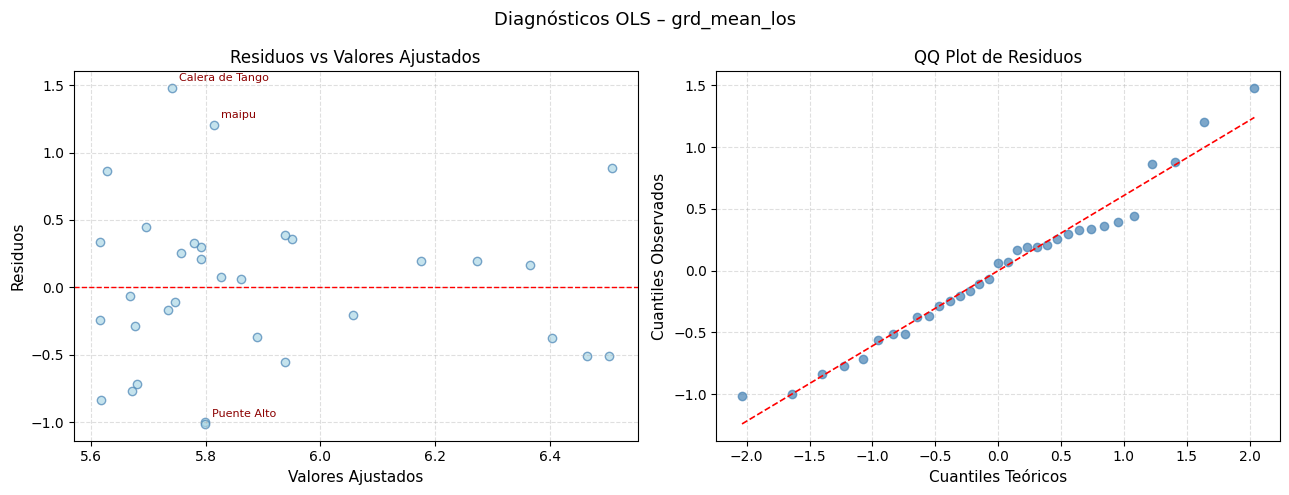


Test de normalidad Shapiro-Wilk:
  W = 0.9707,  p = 0.4998
  → Residuos compatibles con normalidad (p ≥ 0.05).


In [19]:
print("\n" + "="*60)
print("3.3 – Diagnósticos del modelo OLS")
print("="*60)

residuals    = ols_model.resid
fitted       = ols_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gráfico 1: Residuos vs Valores Ajustados ---
ax1 = axes[0]
ax1.scatter(fitted, residuals, alpha=0.7, edgecolors='steelblue', facecolors='lightblue')
ax1.axhline(0, color='red', linestyle='--', linewidth=1)

# Etiquetar los 3 residuos más extremos
top3_idx = residuals.abs().nlargest(3).index
for idx in top3_idx:
    ax1.annotate(
        ols_df.loc[idx, 'nombre_comuna'],
        xy=(fitted[idx], residuals[idx]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        color='darkred'
    )

ax1.set_xlabel('Valores Ajustados', fontsize=11)
ax1.set_ylabel('Residuos', fontsize=11)
ax1.set_title('Residuos vs Valores Ajustados', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)

# --- Gráfico 2: QQ Plot ---
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax2.plot(osm, osr, 'o', alpha=0.7, color='steelblue')
ax2.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.2)
ax2.set_xlabel('Cuantiles Teóricos', fontsize=11)
ax2.set_ylabel('Cuantiles Observados', fontsize=11)
ax2.set_title('QQ Plot de Residuos', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Diagnósticos OLS – grd_mean_los', fontsize=13)
plt.tight_layout()
plt.savefig('output/fig_3_3_diagnosticos_ols.png', dpi=150)
plt.show()

# Test de normalidad Shapiro-Wilk
stat, p_shapiro = stats.shapiro(residuals)
print(f"\nTest de normalidad Shapiro-Wilk:")
print(f"  W = {stat:.4f},  p = {p_shapiro:.4f}")
if p_shapiro < 0.05:
    print("  → Residuos NO normales (p < 0.05). Supuesto de normalidad cuestionable.")
else:
    print("  → Residuos compatibles con normalidad (p ≥ 0.05).")

## 3.3 – Diagnósticos OLS

**Residuos vs Valores Ajustados:** los residuos se distribuyen de forma relativamente
aleatoria alrededor de cero sin un patrón claro de embudo o curvatura, lo que sugiere
que los supuestos de linealidad y homocedasticidad son razonablemente defendibles.
Calera de Tango y maipu tienen residuos positivos moderados (1.2), y Puente Alto el
residuo más negativo (-1.0), pero ninguno es extremo.

**QQ Plot:** los puntos siguen de cerca la línea de 45°, con leve desviación en las
colas. El test de Shapiro-Wilk confirma normalidad (W = 0.979, p = 0.490), por lo que
el supuesto de normalidad de los residuos es defendible.

**Conclusión:** los supuestos de OLS son aceptables para este dataset. El problema
principal no es técnico sino sustantivo: con N=33 y R²=0.18, el modelo tiene poca
potencia. Una extensión natural sería incorporar variables de infraestructura hospitalaria
por comuna (número de camas, tipo de establecimiento) que probablemente expliquen mejor
la duración de estadía que las covariables demográficas disponibles.

## Parte 4 – Falacia Ecológica

### 1. Diferencia entre asociación individual y ecológica

Una asociación ecológica se observa cuando la unidad de análisis es un agregado geográfico
— en este caso, la comuna — y no el individuo. Cuando decimos que comunas con mayor
`pct_foreign` tienen tasas de notificación ENO más altas, estamos describiendo una
relación entre promedios comunales: no estamos afirmando nada sobre si una persona
extranjera en particular tiene mayor probabilidad de ser notificada. La falacia ecológica
(Robinson, 1950) ocurre cuando se asume que la asociación observada a nivel agregado
implica la misma asociación a nivel individual. Este salto es inválido porque dentro de
cada comuna conviven individuos muy heterogéneos, y la composición interna puede producir
correlaciones ecológicas que no existen — o incluso van en sentido contrario — a nivel
individual.

### 2. Ejemplo de mala lectura causal desde nuestros resultados

En el modelo Poisson (antes de corregir por sobredispersión), `pct_foreign` tiene un IRR
de 1.028, estadísticamente significativo. Una mala lectura sería concluir: *"una persona
extranjera tiene un 2.8% más de probabilidad de generar una notificación ENO que una
persona chilena"*. Esto es incorrecto por dos razones. Primero, el coeficiente describe
la relación entre la *proporción comunal* de extranjeros y el *total comunal* de
notificaciones — no compara individuos. Segundo, comunas con más migrantes tienden a ser
comunas urbanas densas con mejor acceso al sistema de salud, lo que por sí solo aumenta
las tasas de notificación independientemente de la nacionalidad. La asociación ecológica
puede estar capturando urbanización, no migración.

### 3. Utilidad ecológica para planificación sanitaria

Aunque no podemos hacer afirmaciones causales individuales, la asociación ecológica entre
`dependency_ratio_census` y `grd_mean_los` (coef = -0.014, p = 0.044) sí es útil para
planificación. Una autoridad de salud puede identificar qué comunas tienen razones de
dependencia altas y anticipar patrones de demanda hospitalaria, independientemente de si
el mecanismo opera a nivel individual. El valor está en la *focalización territorial* de
recursos: si ciertas comunas muestran consistentemente tasas de egreso hospitalario
elevadas asociadas a su perfil demográfico, eso justifica políticas diferenciadas por
territorio sin necesidad de establecer causalidad individual.

### 4. Amenazas adicionales a la inferencia

Un supuesto no abordado en los modelos es la **autocorrelación espacial**: comunas
geográficamente contiguas en la RM tienden a compartir características socioeconómicas
y a compartir infraestructura hospitalaria (un hospital en una comuna atiende pacientes
de comunas vecinas). Esto viola el supuesto de independencia de las observaciones en
nuestros modelos GLM y OLS, pudiendo inflar la significancia aparente de algunos
coeficientes. Una extensión natural sería aplicar modelos de regresión espacial
(SAR o CAR) o al menos incluir un test de Moran sobre los residuos para cuantificar
la dependencia espacial. Adicionalmente, el **N pequeño** (31–33 comunas según el modelo)
limita severamente la potencia estadística y hace que los intervalos de confianza sean
muy amplios, como se observa en la Binomial Negativa donde ningún coeficiente alcanza
significancia.


# Parte 5 – Spatial Visualization of Model Output


# 5.1 – Mapa de tasas predichas (modelo primario ENO: NegBin) / 5.2 - Mapa 5.2: Residuos de Pearson


GeoDataFrame cargado: (52, 12)
Columnas: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry']
Comunas con datos del modelo: 29
Comunas sin datos (NaN):      23


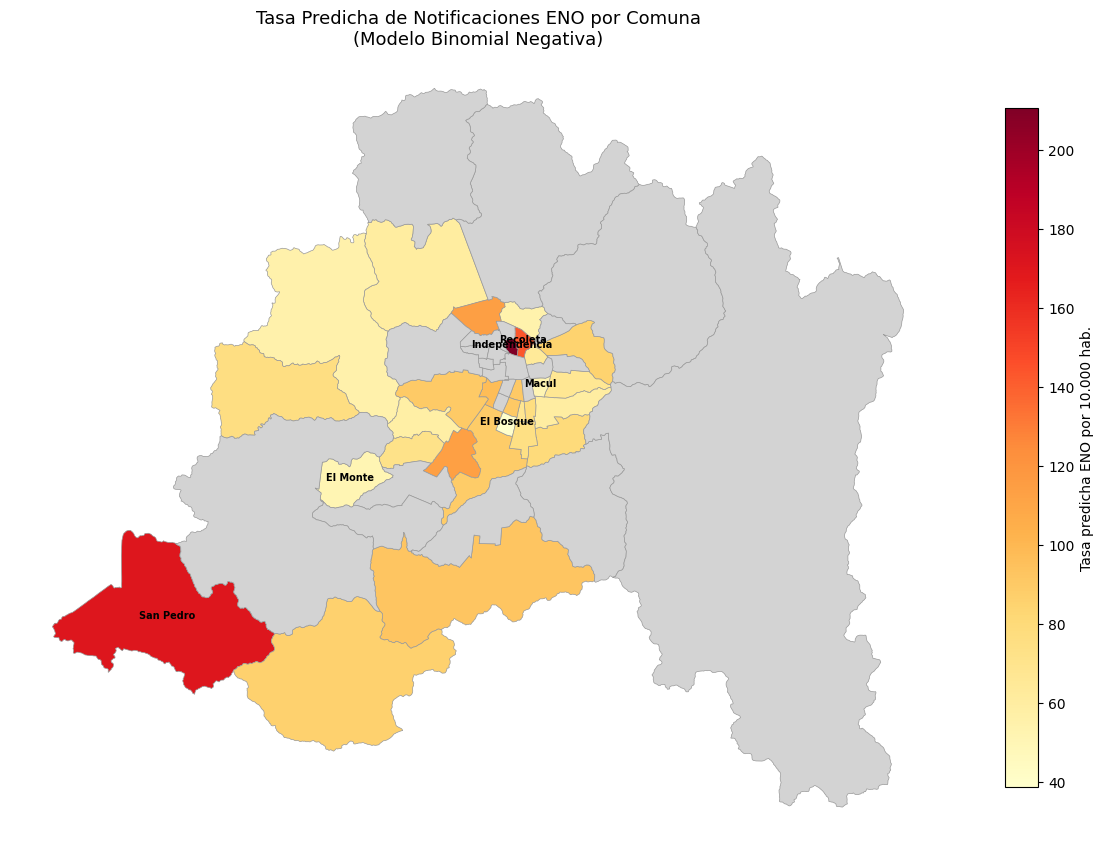

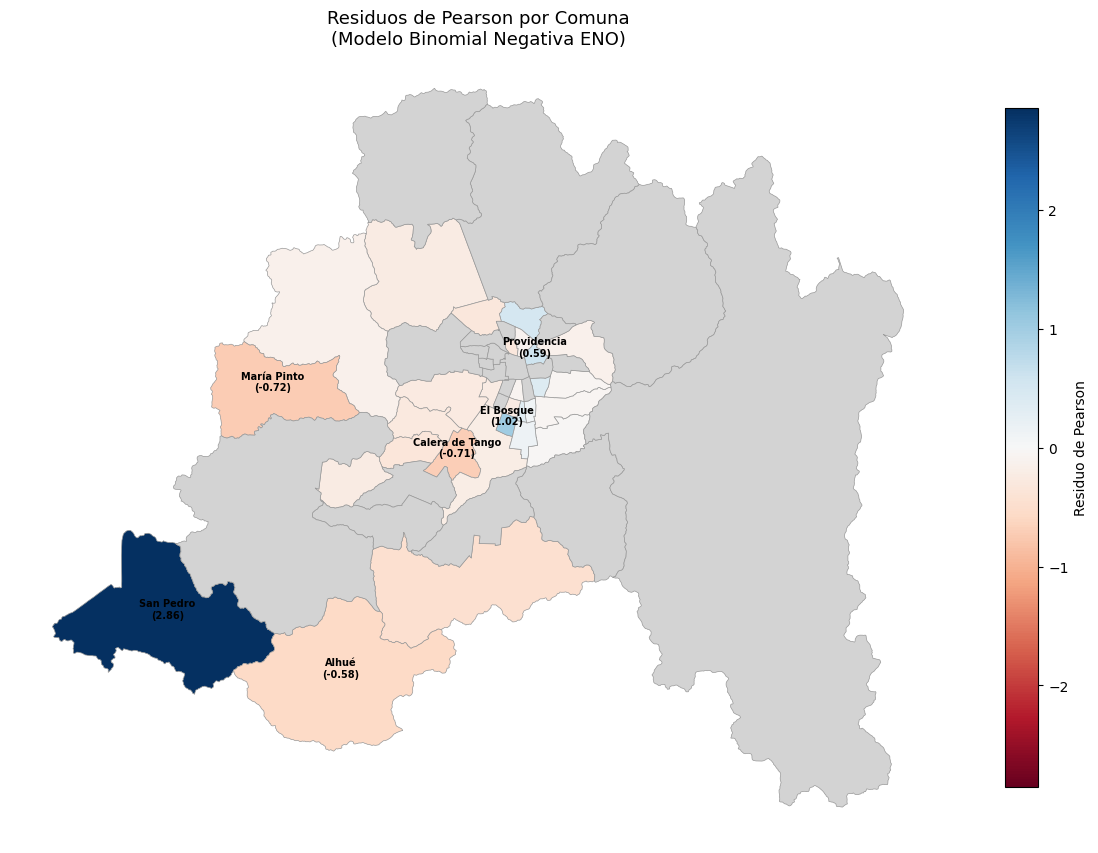


Comunas con residuos de Pearson más positivos (modelo subestima):
     Comuna  pearson_resid
  San Pedro       2.857233
  El Bosque       1.015801
Providencia       0.586158

Comunas con residuos de Pearson más negativos (modelo sobreestima):
         Comuna  pearson_resid
    María Pinto      -0.722371
Calera de Tango      -0.707799
          Alhué      -0.575525


In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# Cargar GeoDataFrame de comunas RM

import geopandas as gpd

url2 = "https://raw.githubusercontent.com/caracena/chile-geojson/master/13.geojson"
gdf_comunas = gpd.read_file(url2)
print(f"GeoDataFrame cargado: {gdf_comunas.shape}")
print(f"Columnas: {gdf_comunas.columns.tolist()}")

# Calcular tasas predichas del modelo NegBin ENO
model_df['predicted_count'] = primary_eno.predict()
model_df['predicted_rate_per_10k'] = (
    model_df['predicted_count'] / model_df['pop_total_census'] * 10000
)

# Calcular residuos de Pearson
model_df['pearson_resid'] = primary_eno.resid_pearson

# Preparar datos para merge con GeoDataFrame
map_data = model_df[['codigo_comuna', 'nombre_comuna',
                      'predicted_rate_per_10k', 'pearson_resid']].copy()
map_data['codigo_comuna'] = map_data['codigo_comuna'].astype(str)

# Preparar GeoDataFrame
gdf = gdf_comunas.copy()
gdf['cod_comuna'] = gdf['cod_comuna'].astype(str)

# Merge
gdf_merged = gdf.merge(map_data, left_on='cod_comuna', right_on='codigo_comuna', how='left')
print(f"Comunas con datos del modelo: {gdf_merged['predicted_rate_per_10k'].notna().sum()}")
print(f"Comunas sin datos (NaN):      {gdf_merged['predicted_rate_per_10k'].isna().sum()}")

# --- Mapa 5.1: Tasa predicha ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf_merged.plot(
    column='predicted_rate_per_10k',
    cmap='YlOrRd',
    linewidth=0.5,
    edgecolor='0.6',
    legend=True,
    legend_kwds={'label': 'Tasa predicha ENO por 10.000 hab.', 'shrink': 0.7},
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    ax=ax
)

# Etiquetar comunas con tasa más alta y más baja
top3 = gdf_merged.nlargest(3, 'predicted_rate_per_10k')
bot3 = gdf_merged.nsmallest(3, 'predicted_rate_per_10k')
for _, row in pd.concat([top3, bot3]).iterrows():
    if row.geometry is not None:
        ax.annotate(
            row['Comuna'],
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=7,
            ha='center',
            color='black',
            fontweight='bold'
        )

ax.set_title('Tasa Predicha de Notificaciones ENO por Comuna\n(Modelo Binomial Negativa)',
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('output/fig_5_1_mapa_tasa_predicha.png', dpi=150)
plt.show()

# --- Mapa 5.2: Residuos de Pearson ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Paleta divergente centrada en 0
vmax = gdf_merged['pearson_resid'].abs().max()

gdf_merged.plot(
    column='pearson_resid',
    cmap='RdBu',
    linewidth=0.5,
    edgecolor='0.6',
    legend=True,
    legend_kwds={'label': 'Residuo de Pearson', 'shrink': 0.7},
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    vmin=-vmax,
    vmax=vmax,
    ax=ax
)

# Etiquetar los 3 residuos más extremos positivos y negativos
top_pos = gdf_merged.nlargest(3, 'pearson_resid')
top_neg = gdf_merged.nsmallest(3, 'pearson_resid')
for _, row in pd.concat([top_pos, top_neg]).iterrows():
    if row.geometry is not None and pd.notna(row['pearson_resid']):
        ax.annotate(
            f"{row['Comuna']}\n({row['pearson_resid']:.2f})",
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=7,
            ha='center',
            color='black',
            fontweight='bold'
        )

ax.set_title('Residuos de Pearson por Comuna\n(Modelo Binomial Negativa ENO)',
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('output/fig_5_2_mapa_residuos.png', dpi=150)
plt.show()

# Reportar comunas con residuos más extremos
print("\nComunas con residuos de Pearson más positivos (modelo subestima):")
print(gdf_merged.nlargest(3, 'pearson_resid')[['Comuna', 'pearson_resid']].to_string(index=False))
print("\nComunas con residuos de Pearson más negativos (modelo sobreestima):")
print(gdf_merged.nsmallest(3, 'pearson_resid')[['Comuna', 'pearson_resid']].to_string(index=False))

## 5.1 – Mapa de Tasas Predichas

El mapa muestra la tasa predicha de notificaciones ENO por 10.000 habitantes según el
modelo Binomial Negativa. Las comunas con mayor tasa predicha se concentran en el sector
sur-poniente de la RM y en comunas periféricas con mayor proporción de población extranjera
y desempleo. Las comunas grises no tienen datos en el pool (equipos que no subieron sus
archivos al Canvas).

## 5.2 – Mapa de Residuos de Pearson

**San Pedro** presenta el residuo más positivo (2.86), lo que indica que el modelo
subestima considerablemente sus notificaciones ENO reales. Esto es consistente con lo
observado en la Parte 1.3: San Pedro tiene una tasa ENO muy superior a lo que predicen
sus covariables demográficas, posiblemente por su condición de comuna turística con alta
rotación de población no residente.

**El Bosque** también tiene residuo positivo (1.02), sugiriendo que sus notificaciones
superan lo esperado dado su perfil demográfico — podría reflejar mayor acceso o uso del
sistema de salud en esa zona.

En el extremo opuesto, **María Pinto** (-0.72) y **Calera de Tango** (-0.71) tienen
residuos negativos: el modelo sobreestima sus notificaciones, probablemente porque son
comunas rurales pequeñas donde el subregistro o el acceso limitado al sistema de salud
deprime las tasas observadas.

# 5.3 – Coeficiente plot (Forest plot) – modelo primario ENO

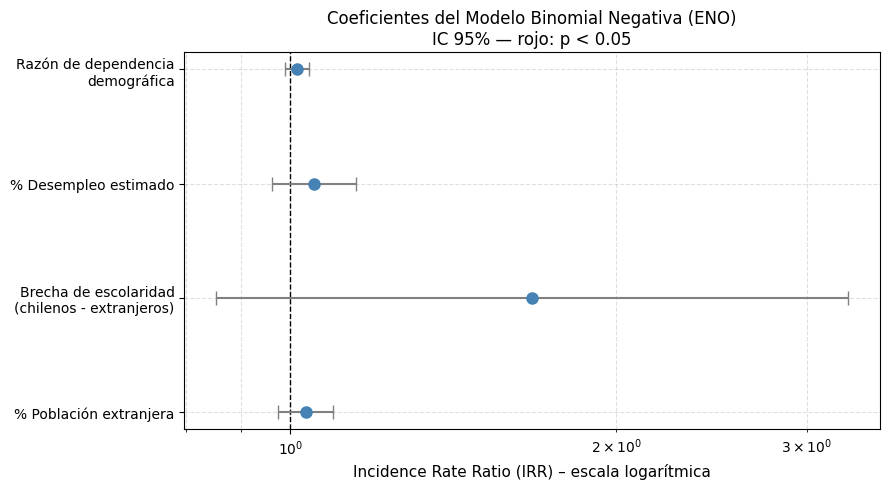

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

# Extraer parámetros e IC del modelo NegBin ENO (sin intercepto)
params  = primary_eno.params.drop('const')
ci      = primary_eno.conf_int().drop('const')
irr     = np.exp(params)
irr_lo  = np.exp(ci[0])
irr_hi  = np.exp(ci[1])
pvals   = primary_eno.pvalues.drop('const')

# Etiquetas legibles
labels = {
    'pct_foreign':              '% Población extranjera',
    'schooling_gap':            'Brecha de escolaridad\n(chilenos - extranjeros)',
    'pct_unemployed':           '% Desempleo estimado',
    'dependency_ratio_census':  'Razón de dependencia\ndemográfica',
}
names = [labels.get(p, p) for p in params.index]
y_pos = range(len(names))

# Colores según significancia
colors = ['crimson' if p < 0.05 else 'steelblue' for p in pvals]

ax.errorbar(
    x=irr,
    y=list(y_pos),
    xerr=[irr - irr_lo, irr_hi - irr],
    fmt='o',
    color='black',
    ecolor='grey',
    capsize=5,
    markersize=7,
    zorder=3
)

# Colorear puntos según significancia
for i, (x, y, c) in enumerate(zip(irr, y_pos, colors)):
    ax.plot(x, y, 'o', color=c, markersize=8, zorder=4)

# Línea nula IRR = 1
ax.axvline(x=1, color='black', linestyle='--', linewidth=1, zorder=2)

ax.set_xscale('log')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('Incidence Rate Ratio (IRR) – escala logarítmica', fontsize=11)
ax.set_title('Coeficientes del Modelo Binomial Negativa (ENO)\nIC 95% — rojo: p < 0.05',
             fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('output/fig_5_3_coeficiente_plot.png', dpi=150)
plt.show()

## 5.3 – Coeficiente Plot

El forest plot muestra los IRR del modelo Binomial Negativa para ENO. Todos los
intervalos de confianza cruzan la línea nula (IRR = 1), confirmando que ningún coeficiente
es estadísticamente significativo al 5% — representado en azul. La brecha de escolaridad
tiene el IRR puntual más alejado de 1 (~1.67) pero con un intervalo de confianza muy
amplio, reflejo del N pequeño (31 comunas). Esto refuerza la conclusión de la Parte 2.3:
las direcciones de los efectos son plausibles pero la incertidumbre es demasiado grande
para conclusiones definitivas.

## Parte 6 – Síntesis Integrada

### 1. Retrato demográfico de la Región Metropolitana (Tarea 1)

A nivel comunal, la RM muestra una heterogeneidad demográfica marcada a lo largo de un
eje socioeconómico que va desde comunas de alto ingreso y alta escolaridad en el sector
oriente (Providencia, Las Condes, La Reina) hasta comunas periféricas con mayor
vulnerabilidad en el sur y poniente (La Pintana, El Bosque, San Ramón). El eje dominante
de variación entre comunas es la combinación de **nivel educativo y proporción de
población extranjera**: las comunas con mayor `pct_foreign` (Independencia: 44%,
San Miguel: 27%) tienden a concentrarse en el sector central y norte de Santiago,
mientras que comunas rurales como Alhué, María Pinto y Pirque tienen menos del 4% de
población migrante. Las comunas del Grupo 15 ilustran bien este gradiente: Providencia
(12% extranjeros, escolaridad promedio 16.5 años) y San Miguel (27% extranjeros,
escolaridad 14.3 años) representan el polo urbano-migrante, mientras que Paine (8%
extranjeros, escolaridad 11.1 años) representa el polo rural-periférico.

### 2. Paisaje sanitario y su relación con el eje demográfico (Tarea 2)

Las tasas de notificación ENO y de egresos hospitalarios GRD no siguen de forma simple
el mismo eje demográfico. Para ENO, comunas centrales como Independencia (140 por 10k)
y Recoleta (128 por 10k) tienen tasas elevadas, consistente con su alta densidad
migratoria y mejor acceso al sistema de salud. Sin embargo, San Pedro (658 por 10k)
rompe completamente la tendencia: su tasa ENO es 5 veces mayor que la segunda comuna
más alta, no por composición demográfica sino por su condición de destino turístico que
infla las notificaciones relativas a su población residente. Para GRD, el patrón es
inverso: comunas rurales periféricas como San José de Maipo (1.631 por 10k), San Ramón
(1.545 por 10k) y La Pintana (1.457 por 10k) tienen las tasas de egreso más altas,
mientras que comunas de alto ingreso como Las Condes (364 por 10k) y Pudahuel (479 por
10k) tienen las más bajas. Esto sugiere que el eje demográfico predice mejor el uso del
sistema de notificación que el uso hospitalario, donde entran en juego factores de oferta
(localización de hospitales, derivaciones entre comunas) que no están capturados en las
covariables del censo.

### 3. Qué agregan los modelos cross-dataset (Tarea 3)

Los modelos de conteo revelan tres hallazgos que no son visibles en la matriz de
correlación. Primero, la **sobredispersión extrema** (dispersión Poisson ENO = 190,
GRD = 2313) indica que la varianza entre comunas en notificaciones y egresos es mucho
mayor de lo que cualquier modelo lineal simple capturaría: hay comunas que se comportan
como casos atípicos estructurales, no solo ruido. Segundo, el paso de Poisson a Binomial
Negativa muestra que las correlaciones observadas en la Parte 1 (por ejemplo, r = 0.30
entre `schooling_gap` y `eno_rate_per_10k`) son en gran parte producto de errores
estándar subestimados — al corregir por sobredispersión, ningún coeficiente alcanza
significancia, lo que la correlación bivariada no advertía. Tercero, el mapa de residuos
de la Parte 5 identifica a **San Pedro** como un outlier estructural (residuo de Pearson
= 2.86) que ningún dataset individual señalaba como problemático: solo al cruzar la tasa
ENO con las covariables demográficas del censo se hace evidente que su comportamiento
no es explicable por su composición poblacional. Esto ilustra el valor del análisis
cross-dataset: no para confirmar lo que ya se veía, sino para identificar dónde los
datos se contradicen entre sí y por qué.

In [23]:
import shutil
import os

# Crear carpeta en Drive si no existe
drive_output = "/content/drive/MyDrive/Pre. y Análisis de datos/IELE756_Tarea3_output"
os.makedirs(drive_output, exist_ok=True)

# Copiar todos los archivos de output/ a Drive
for f in os.listdir('output'):
    src = os.path.join('output', f)
    dst = os.path.join(drive_output, f)
    shutil.copy(src, dst)
    print(f"Copiado: {f}")

print(f"\nTodos los archivos guardados en:\n{drive_output}")

Copiado: fig_5_2_mapa_residuos.png
Copiado: fig_3_3_diagnosticos_ols.png
Copiado: tarea3_analytical_table.csv
Copiado: fig_1_2_scatter.png
Copiado: fig_1_1_correlacion.png
Copiado: fig_5_3_coeficiente_plot.png
Copiado: fig_5_1_mapa_tasa_predicha.png

Todos los archivos guardados en:
/content/drive/MyDrive/Pre. y Análisis de datos/IELE756_Tarea3_output


Link con archivos: https://drive.google.com/drive/folders/13Z97DxNnT_S5lLODqB362QPLPaO-qYlv?usp=drive_link

In [24]:
print("fin tarea n°2")

fin tarea n°2
